In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# STEP 1: ID_Release 기준 데이터 준비
# Complete 구간만 Train/Test로 사용
# 마지막 미완성 구간은 Future 예측 대상으로 분리

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")


class DataPreparator:
    def __init__(self, filepath, window_size=4):
        self.filepath = filepath
        self.window_size = window_size
        self.df = None
        self.lag_features = []
        self.internal_features = []

    def load_data(self):
        print("=" * 60)
        print("STEP 1-1. 데이터 로드")
        print("=" * 60)

        self.df = pd.read_csv(self.filepath)
        self.df["Date"] = pd.to_datetime(self.df["Date"])

        if "Release_Date" in self.df.columns:
            self.df["Release_Date"] = pd.to_datetime(self.df["Release_Date"])

        required_cols = ["ZF_PN", "ID_Release", "Date", "Quantity", "is_firm"]

        for col in required_cols:
            if col not in self.df.columns:
                raise ValueError(f"필수 컬럼이 없습니다: {col}")

        self.df = self.df.sort_values(
            ["ZF_PN", "ID_Release", "Date"]
        ).reset_index(drop=True)

        print(f"데이터 크기: {self.df.shape}")
        print(f"Demand Date 범위: {self.df['Date'].min()} ~ {self.df['Date'].max()}")

        if "Release_Date" in self.df.columns:
            print(f"Release_Date 범위: {self.df['Release_Date'].min()} ~ {self.df['Release_Date'].max()}")

        print(f"품명 수: {self.df['ZF_PN'].nunique()}")
        print(f"ID_Release 수: {self.df['ID_Release'].nunique()}")
        print(f"is_firm 평균: {self.df['is_firm'].mean():.3f}")

        return self

    def engineer_features(self):
        print("\n" + "=" * 60)
        print("STEP 1-2. Feature Engineering")
        print("=" * 60)

        self.df["Year"] = self.df["Date"].dt.year
        self.df["Month_Num"] = self.df["Date"].dt.month
        self.df["Day"] = self.df["Date"].dt.day
        self.df["DayOfYear"] = self.df["Date"].dt.dayofyear
        self.df["WeekOfYear"] = self.df["Date"].dt.isocalendar().week.astype(int)
        self.df["Quarter"] = self.df["Date"].dt.quarter
        self.df["DayOfWeek"] = self.df["Date"].dt.dayofweek

        if "Release_Date" in self.df.columns:
            self.df["DaysSinceRelease"] = (
                self.df["Date"] - self.df["Release_Date"]
            ).dt.days
            self.df["WeeksSinceRelease"] = self.df["DaysSinceRelease"] / 7
        else:
            self.df["DaysSinceRelease"] = 0
            self.df["WeeksSinceRelease"] = 0

        group_cols = ["ZF_PN", "ID_Release"]

        self.df["Quantity_Rolling_Mean_2w"] = (
            self.df.groupby(group_cols)["Quantity"]
            .transform(lambda x: x.shift(1).rolling(window=2, min_periods=1).mean())
        )

        self.df["Quantity_Rolling_Std_2w"] = (
            self.df.groupby(group_cols)["Quantity"]
            .transform(lambda x: x.shift(1).rolling(window=2, min_periods=1).std().fillna(0))
        )

        self.df["Quantity_Rolling_Mean_4w"] = (
            self.df.groupby(group_cols)["Quantity"]
            .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).mean())
        )

        self.df["Quantity_Rolling_Std_4w"] = (
            self.df.groupby(group_cols)["Quantity"]
            .transform(lambda x: x.shift(1).rolling(window=4, min_periods=1).std().fillna(0))
        )

        print("✓ Feature Engineering 완료")
        print("  - Rolling 통계량은 과거 데이터만 사용")

        return self

    def create_firm_ratio_target(self):
        print("\n" + "=" * 60)
        print("STEP 1-3. FIRM_RATIO 타깃 생성")
        print("=" * 60)

        self.df["FIRM_RATIO"] = np.nan
        group_cols = ["ZF_PN", "ID_Release"]

        for _, group in self.df.groupby(group_cols):
            idx_list = group.sort_values("Date").index.tolist()

            for i, idx in enumerate(idx_list):
                future_idx = idx_list[i + 1:i + 1 + self.window_size]

                if len(future_idx) > 0:
                    self.df.loc[idx, "FIRM_RATIO"] = self.df.loc[future_idx, "is_firm"].mean()

        valid_ratio = self.df["FIRM_RATIO"].dropna()

        print(f"✓ FIRM_RATIO 생성 완료")
        print(f"  정의: 현재 이후 미래 {self.window_size}주 동안 is_firm=1 비율")
        print(f"  유효 데이터: {len(valid_ratio):,} / {len(self.df):,}")
        print(f"  평균: {valid_ratio.mean():.3f}")
        print(f"  표준편차: {valid_ratio.std():.3f}")
        print(f"  최소값: {valid_ratio.min():.3f}")
        print(f"  최대값: {valid_ratio.max():.3f}")

        print("\n[FIRM_RATIO 분포]")
        distribution = self.df["FIRM_RATIO"].value_counts().sort_index()
        for ratio, count in distribution.items():
            if not pd.isna(ratio):
                print(f"  {ratio:.2f}: {count:,}개")

        return self

    def identify_feature_groups(self):
        print("\n" + "=" * 60)
        print("STEP 1-4. 변수 그룹 분리")
        print("=" * 60)

        self.lag_features = [
            col for col in self.df.columns
            if "lag" in col.lower()
            and pd.api.types.is_numeric_dtype(self.df[col])
        ]

        exclude_cols = {
            "ZF_PN",
            "Supplier_PN",
            "Order",
            "ID_Release",
            "Date",
            "Release_Date",
            "UN",
            "Month",
            "Firm_Forecast",
            "Shipping_Inst",
            "Shipped_Invoice",
            "is_firm",
            "FIRM_RATIO",
            "Quantity"
        }

        self.internal_features = [
            col for col in self.df.columns
            if col not in exclude_cols
            and col not in self.lag_features
            and pd.api.types.is_numeric_dtype(self.df[col])
        ]

        print(f"\n외부 변수 Lag Features: {len(self.lag_features)}개")
        for col in self.lag_features:
            print(f"  - {col}")

        print(f"\n내부 변수 Internal Features: {len(self.internal_features)}개")
        for col in self.internal_features:
            print(f"  - {col}")

        return self

    def handle_missing_values(self):
        print("\n" + "=" * 60)
        print("STEP 1-5. 결측치 처리")
        print("=" * 60)

        model_cols = (
            ["ZF_PN", "ID_Release", "Date", "Quantity", "is_firm", "FIRM_RATIO"]
            + self.lag_features
            + self.internal_features
        )

        if "Order" in self.df.columns:
            model_cols.append("Order")

        model_cols = [col for col in model_cols if col in self.df.columns]
        df_model = self.df[model_cols].copy()

        print("\n[처리 전 결측치]")
        missing_before = df_model.isna().sum()
        missing_cols = missing_before[missing_before > 0]

        if len(missing_cols) > 0:
            for col, count in missing_cols.items():
                print(f"  {col}: {count:,}개")
        else:
            print("  없음")

        numeric_cols = df_model.select_dtypes(include=[np.number]).columns

        df_model[numeric_cols] = (
            df_model
            .groupby(["ZF_PN", "ID_Release"])[numeric_cols]
            .transform(lambda x: x.ffill())
        )

        df_model[numeric_cols] = df_model[numeric_cols].fillna(0)

        df_model = df_model.dropna(
            subset=["ZF_PN", "ID_Release", "Date"]
        ).reset_index(drop=True)

        print("\n[처리 후 결측치]")
        missing_after = df_model.isna().sum()
        missing_cols_after = missing_after[missing_after > 0]

        if len(missing_cols_after) > 0:
            for col, count in missing_cols_after.items():
                print(f"  {col}: {count:,}개")
        else:
            print("  ✓ 결측치 없음")

        print(f"\n최종 데이터 크기: {df_model.shape}")

        self.df = df_model

        return self

    def count_future_firm_cases(self, df):
        count = 0

        for _, g in df.groupby(["ZF_PN", "ID_Release"]):
            g = g.sort_values("Date").reset_index(drop=True)

            has_future_firm = False

            for i in range(len(g)):
                future = g.iloc[i + 1:i + 1 + self.window_size]

                if len(future) > 0 and (future["is_firm"] == 1).any():
                    has_future_firm = True
                    break

            if has_future_firm:
                count += 1

        return count

    def split_complete_future(self, train_ratio=0.75):
        print("\n" + "=" * 60)
        print("STEP 1-6. Complete / Future 분리 후 Train / Test Split")
        print("=" * 60)

        max_date = self.df["Date"].max()
        cutoff_date = max_date - pd.Timedelta(weeks=self.window_size)

        complete_df = self.df[self.df["Date"] <= cutoff_date].copy()
        future_df = self.df[self.df["Date"] > cutoff_date].copy()

        print(f"전체 마지막 Date: {max_date}")
        print(f"Complete cutoff Date: {cutoff_date}")
        print(f"Complete 데이터: {complete_df.shape}")
        print(f"Future 데이터  : {future_df.shape}")

        release_dates = (
            complete_df.groupby(["ZF_PN", "ID_Release"])["Date"]
            .min()
            .reset_index()
            .rename(columns={"Date": "Release_Start"})
            .sort_values("Release_Start")
            .reset_index(drop=True)
        )

        n_release = len(release_dates)
        train_end = int(n_release * train_ratio)

        train_keys = release_dates.iloc[:train_end][["ZF_PN", "ID_Release"]]
        test_keys = release_dates.iloc[train_end:][["ZF_PN", "ID_Release"]]

        train_df = complete_df.merge(train_keys, on=["ZF_PN", "ID_Release"], how="inner")
        test_df = complete_df.merge(test_keys, on=["ZF_PN", "ID_Release"], how="inner")

        train_df = train_df.sort_values(["ZF_PN", "ID_Release", "Date"]).reset_index(drop=True)
        test_df = test_df.sort_values(["ZF_PN", "ID_Release", "Date"]).reset_index(drop=True)
        future_df = future_df.sort_values(["ZF_PN", "ID_Release", "Date"]).reset_index(drop=True)

        print("\n[ID_Release 기준 Split]")
        print(f"Complete ID_Release 수: {n_release}")
        print(f"Train ID_Release 수: {len(train_keys)}")
        print(f"Test ID_Release 수 : {len(test_keys)}")

        print("\n[데이터 행 수]")
        print(f"Train : {train_df.shape}")
        print(f"Test  : {test_df.shape}")
        print(f"Future: {future_df.shape}")

        print("\n[FIRM_RATIO 평균]")
        print(f"Train : {train_df['FIRM_RATIO'].mean():.3f}")
        print(f"Test  : {test_df['FIRM_RATIO'].mean():.3f}")
        print(f"Future: {future_df['FIRM_RATIO'].mean():.3f}")

        print("\n[미래 Firm 발생 케이스 확인]")
        print(f"Train : {self.count_future_firm_cases(train_df)}")
        print(f"Test  : {self.count_future_firm_cases(test_df)}")
        print("Future: 평가용 아님 / 실제 예측 대상")

        return train_df, test_df, future_df

    def prepare_datasets(self):
        self.load_data()
        self.engineer_features()
        self.create_firm_ratio_target()
        self.identify_feature_groups()
        self.handle_missing_values()

        train_df, test_df, future_df = self.split_complete_future(
            train_ratio=0.75
        )

        feature_info = {
            "lag_features": self.lag_features,
            "internal_features": self.internal_features,
            "all_features": self.lag_features + self.internal_features
        }

        return train_df, test_df, future_df, feature_info


if __name__ == "__main__":
    DATA_PATH = "/content/A0049000_only_selected_features.csv"

    preparator = DataPreparator(
        filepath=DATA_PATH,
        window_size=4
    )

    train_df, test_df, future_df, feature_info = preparator.prepare_datasets()

    print("\n" + "=" * 60)
    print("✓ STEP 1 완료: 데이터 준비")
    print("=" * 60)

    print(f"\n[데이터셋 크기]")
    print(f"  Train : {train_df.shape}")
    print(f"  Test  : {test_df.shape}")
    print(f"  Future: {future_df.shape}")

    print(f"\n[외부 변수 Lag Features] - {len(feature_info['lag_features'])}개")
    for col in feature_info["lag_features"]:
        print(f"  - {col}")

    print(f"\n[내부 변수 Internal Features] - {len(feature_info['internal_features'])}개")
    for col in feature_info["internal_features"]:
        print(f"  - {col}")

STEP 1-1. 데이터 로드
데이터 크기: (5359, 19)
Demand Date 범위: 2024-05-27 00:00:00 ~ 2027-07-30 00:00:00
Release_Date 범위: 2024-05-21 00:00:00 ~ 2025-11-10 00:00:00
품명 수: 1
ID_Release 수: 77
is_firm 평균: 0.057

STEP 1-2. Feature Engineering
✓ Feature Engineering 완료
  - Rolling 통계량은 과거 데이터만 사용

STEP 1-3. FIRM_RATIO 타깃 생성
✓ FIRM_RATIO 생성 완료
  정의: 현재 이후 미래 4주 동안 is_firm=1 비율
  유효 데이터: 5,282 / 5,359
  평균: 0.024
  표준편차: 0.127
  최소값: 0.000
  최대값: 1.000

[FIRM_RATIO 분포]
  0.00: 5,052개
  0.25: 74개
  0.50: 68개
  0.75: 48개
  1.00: 40개

STEP 1-4. 변수 그룹 분리

외부 변수 Lag Features: 4개
  - OIL_FACTOR__level_lag11
  - SHIP_FACTOR__level_lag6
  - GSCPI__level_lag14
  - Brazil_CPI__level_lag3

내부 변수 Internal Features: 13개
  - Year
  - Day
  - Month_Num
  - DayOfYear
  - WeekOfYear
  - Quarter
  - DayOfWeek
  - DaysSinceRelease
  - WeeksSinceRelease
  - Quantity_Rolling_Mean_2w
  - Quantity_Rolling_Std_2w
  - Quantity_Rolling_Mean_4w
  - Quantity_Rolling_Std_4w

STEP 1-5. 결측치 처리

[처리 전 결측치]
  FIRM_RATIO: 77개
  Quantity_R

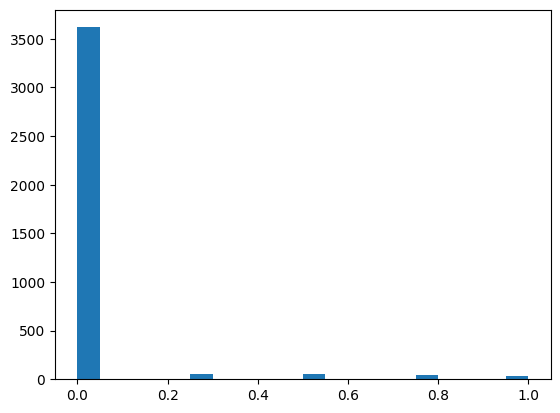

In [3]:
import matplotlib.pyplot as plt
plt.hist(train_df["FIRM_RATIO"], bins=20)
plt.show()


In [5]:
# STEP 2: FIRM_RATIO 하이브리드 회귀 모델
import pickle
import xgboost as xgb

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


class FirmRatioHybridModel:
    def __init__(
        self,
        lag_features,
        internal_features,
        weight_strength=30,
        residual_model_type="ridge",
        alpha=1.0
    ):
        self.lag_features = lag_features
        self.internal_features = internal_features
        self.weight_strength = weight_strength
        self.residual_model_type = residual_model_type
        self.alpha = alpha

        self.xgb_model = None
        self.residual_model = None
        self.use_hybrid = len(lag_features) > 0

    def get_sample_weight(self, y):
        return 1 + self.weight_strength * y

    def evaluate(self, y_true, y_pred, name="Model"):
        y_pred = np.clip(y_pred, 0, 1)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        zero_ratio = np.mean(y_pred < 0.05)
        high_ratio_005 = np.mean(y_pred >= 0.05)
        high_ratio_010 = np.mean(y_pred >= 0.10)
        high_ratio_020 = np.mean(y_pred >= 0.20)

        print(f"\n[{name}]")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE : {mae:.4f}")
        print(f"  R²  : {r2:.4f}")
        print(f"  예측값 < 0.05 비율 : {zero_ratio:.2%}")
        print(f"  예측값 >= 0.05 비율: {high_ratio_005:.2%}")
        print(f"  예측값 >= 0.10 비율: {high_ratio_010:.2%}")
        print(f"  예측값 >= 0.20 비율: {high_ratio_020:.2%}")

        return {
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "zero_ratio": zero_ratio,
            "high_ratio_005": high_ratio_005,
            "high_ratio_010": high_ratio_010,
            "high_ratio_020": high_ratio_020
        }

    def fit(self, train_df, eval_df):
        print("\n" + "=" * 60)
        print("STEP 2: FIRM_RATIO 하이브리드 회귀 모델")
        print("=" * 60)

        print("\n[Phase 1] XGBoost 학습 - 내부 변수")
        print(f"  내부 변수: {len(self.internal_features)}개")

        X_train_internal = train_df[self.internal_features]
        y_train = train_df["FIRM_RATIO"]

        X_eval_internal = eval_df[self.internal_features]
        y_eval = eval_df["FIRM_RATIO"]

        sample_weight = self.get_sample_weight(y_train)

        print("\n[가중치 정보]")
        print(f"  weight_strength: {self.weight_strength}")
        print(f"  min: {sample_weight.min():.2f}")
        print(f"  max: {sample_weight.max():.2f}")
        print(f"  mean: {sample_weight.mean():.2f}")

        self.xgb_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_weight=5,
            gamma=0.1,
            reg_alpha=0.5,
            reg_lambda=3.0,
            random_state=42
        )

        self.xgb_model.fit(
            X_train_internal,
            y_train,
            sample_weight=sample_weight,
            eval_set=[(X_eval_internal, y_eval)],
            verbose=False
        )

        train_pred_xgb = np.clip(self.xgb_model.predict(X_train_internal), 0, 1)
        eval_pred_xgb = np.clip(self.xgb_model.predict(X_eval_internal), 0, 1)

        print("\n✓ XGBoost 학습 완료")
        xgb_train_metrics = self.evaluate(y_train, train_pred_xgb, "XGBoost Train")
        xgb_eval_metrics = self.evaluate(y_eval, eval_pred_xgb, "XGBoost Eval/Test")

        if self.use_hybrid:
            print(f"\n[Phase 2] {self.residual_model_type.upper()} 잔차 보정 - 외부 변수")
            print(f"  외부 변수: {len(self.lag_features)}개")

            train_residual = y_train - train_pred_xgb

            X_train_lag = train_df[self.lag_features]
            X_eval_lag = eval_df[self.lag_features]

            if self.residual_model_type == "ridge":
                self.residual_model = Ridge(alpha=self.alpha, random_state=42)
            elif self.residual_model_type == "lasso":
                self.residual_model = Lasso(alpha=self.alpha, random_state=42)
            else:
                raise ValueError("residual_model_type은 'ridge' 또는 'lasso'만 가능합니다.")

            self.residual_model.fit(X_train_lag, train_residual)

            train_residual_pred = self.residual_model.predict(X_train_lag)
            eval_residual_pred = self.residual_model.predict(X_eval_lag)

            train_pred_final = np.clip(train_pred_xgb + train_residual_pred, 0, 1)
            eval_pred_final = np.clip(eval_pred_xgb + eval_residual_pred, 0, 1)

            print("\n✓ 잔차 보정 완료")
            print(f"  잔차 평균: {train_residual.mean():.4f}")
            print(f"  잔차 표준편차: {train_residual.std():.4f}")

            hybrid_train_metrics = self.evaluate(y_train, train_pred_final, "Hybrid Train")
            hybrid_eval_metrics = self.evaluate(y_eval, eval_pred_final, "Hybrid Eval/Test")

        else:
            print("\n외부 변수 없음 → XGBoost만 사용")
            train_pred_final = train_pred_xgb
            eval_pred_final = eval_pred_xgb
            hybrid_train_metrics = xgb_train_metrics
            hybrid_eval_metrics = xgb_eval_metrics

        print("\n[내부 변수 Feature Importance Top 10]")
        internal_importance = pd.DataFrame({
            "Feature": self.internal_features,
            "Importance": self.xgb_model.feature_importances_
        }).sort_values("Importance", ascending=False)

        print(internal_importance.head(10).to_string(index=False))

        if self.use_hybrid:
            print("\n[외부 변수 회귀 계수]")
            lag_coef = pd.DataFrame({
                "Feature": self.lag_features,
                "Coefficient": self.residual_model.coef_
            }).sort_values("Coefficient", ascending=False, key=abs)

            print(lag_coef.to_string(index=False))
        else:
            lag_coef = None

        return {
            "xgb_train_metrics": xgb_train_metrics,
            "xgb_eval_metrics": xgb_eval_metrics,
            "hybrid_train_metrics": hybrid_train_metrics,
            "hybrid_eval_metrics": hybrid_eval_metrics,
            "internal_importance": internal_importance,
            "lag_coefficients": lag_coef
        }

    def predict(self, df):
        X_internal = df[self.internal_features]
        pred_xgb = np.clip(self.xgb_model.predict(X_internal), 0, 1)

        if self.use_hybrid:
            X_lag = df[self.lag_features]
            residual_pred = self.residual_model.predict(X_lag)
            pred_final = np.clip(pred_xgb + residual_pred, 0, 1)
        else:
            pred_final = pred_xgb

        return pred_final

    def evaluate_test(self, test_df):
        print("\n" + "=" * 60)
        print("STEP 2-1: Test 평가")
        print("=" * 60)

        y_test = test_df["FIRM_RATIO"]
        pred = self.predict(test_df)

        test_metrics = self.evaluate(y_test, pred, "Final Test")

        result_df = test_df.copy()
        result_df["FIRM_RATIO_Pred"] = pred
        result_df["FIRM_RATIO_Actual"] = y_test.values
        result_df["Error"] = result_df["FIRM_RATIO_Actual"] - result_df["FIRM_RATIO_Pred"]

        print("\n[예측값 분포]")
        print(result_df["FIRM_RATIO_Pred"].describe())

        print("\n[Actual > 0 샘플 예측 확인 상위 30개]")
        high_actual = result_df[result_df["FIRM_RATIO_Actual"] > 0].copy()

        if len(high_actual) > 0:
            print(
                high_actual[
                    ["Date", "ID_Release", "FIRM_RATIO_Actual", "FIRM_RATIO_Pred", "Error"]
                ].head(30).to_string(index=False)
            )
        else:
            print("Actual > 0 샘플 없음")

        return result_df, test_metrics

    def predict_future(self, future_df):
        print("\n" + "=" * 60)
        print("STEP 2-2: Future 구간 예측")
        print("=" * 60)

        pred = self.predict(future_df)

        future_result_df = future_df.copy()
        future_result_df["FIRM_RATIO_Pred"] = pred

        print("\n[Future 예측값 분포]")
        print(future_result_df["FIRM_RATIO_Pred"].describe())

        print("\n[Future 예측값 상위 30개]")
        print(
            future_result_df[
                ["Date", "ID_Release", "FIRM_RATIO_Pred"]
            ].sort_values("FIRM_RATIO_Pred", ascending=False)
             .head(30)
             .to_string(index=False)
        )

        return future_result_df

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self, f)

        print(f"\n✓ 모델 저장 완료: {path}")


# ================= 실행 =================

if __name__ == "__main__":
    DATA_PATH = "/content/A0049000_only_selected_features.csv"

    MODEL_SAVE_PATH = "/content/firm_hybrid_model.pkl"
    TEST_RESULT_SAVE_PATH = "/content/firm_ratio_test_predictions.csv"
    FUTURE_RESULT_SAVE_PATH = "/content/firm_ratio_future_predictions.csv"

    preparator = DataPreparator(
        filepath=DATA_PATH,
        window_size=4
    )

    train_df, test_df, future_df, feature_info = preparator.prepare_datasets()

    model = FirmRatioHybridModel(
        lag_features=feature_info["lag_features"],
        internal_features=feature_info["internal_features"],
        weight_strength=30,
        residual_model_type="ridge",
        alpha=1.0
    )

    importance_dict = model.fit(
        train_df=train_df,
        eval_df=test_df
    )

    test_result_df, test_metrics = model.evaluate_test(test_df)

    future_result_df = model.predict_future(future_df)

    model.save(MODEL_SAVE_PATH)

    test_result_df.to_csv(
        TEST_RESULT_SAVE_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    future_result_df.to_csv(
        FUTURE_RESULT_SAVE_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n" + "=" * 60)
    print("✓ STEP 2 완료")
    print("=" * 60)
    print(f"모델 저장: {MODEL_SAVE_PATH}")
    print(f"Test 결과 저장: {TEST_RESULT_SAVE_PATH}")
    print(f"Future 결과 저장: {FUTURE_RESULT_SAVE_PATH}")


STEP 1-1. 데이터 로드
데이터 크기: (5359, 19)
Demand Date 범위: 2024-05-27 00:00:00 ~ 2027-07-30 00:00:00
Release_Date 범위: 2024-05-21 00:00:00 ~ 2025-11-10 00:00:00
품명 수: 1
ID_Release 수: 77
is_firm 평균: 0.057

STEP 1-2. Feature Engineering
✓ Feature Engineering 완료
  - Rolling 통계량은 과거 데이터만 사용

STEP 1-3. FIRM_RATIO 타깃 생성
✓ FIRM_RATIO 생성 완료
  정의: 현재 이후 미래 4주 동안 is_firm=1 비율
  유효 데이터: 5,282 / 5,359
  평균: 0.024
  표준편차: 0.127
  최소값: 0.000
  최대값: 1.000

[FIRM_RATIO 분포]
  0.00: 5,052개
  0.25: 74개
  0.50: 68개
  0.75: 48개
  1.00: 40개

STEP 1-4. 변수 그룹 분리

외부 변수 Lag Features: 4개
  - OIL_FACTOR__level_lag11
  - SHIP_FACTOR__level_lag6
  - GSCPI__level_lag14
  - Brazil_CPI__level_lag3

내부 변수 Internal Features: 13개
  - Year
  - Day
  - Month_Num
  - DayOfYear
  - WeekOfYear
  - Quarter
  - DayOfWeek
  - DaysSinceRelease
  - WeeksSinceRelease
  - Quantity_Rolling_Mean_2w
  - Quantity_Rolling_Std_2w
  - Quantity_Rolling_Mean_4w
  - Quantity_Rolling_Std_4w

STEP 1-5. 결측치 처리

[처리 전 결측치]
  FIRM_RATIO: 77개
  Quantity_R

STEP 1-1. 데이터 로드
데이터 크기: (5359, 19)
Demand Date 범위: 2024-05-27 00:00:00 ~ 2027-07-30 00:00:00
Release_Date 범위: 2024-05-21 00:00:00 ~ 2025-11-10 00:00:00
품명 수: 1
ID_Release 수: 77
is_firm 평균: 0.057

STEP 1-2. Feature Engineering
✓ Feature Engineering 완료
  - Rolling 통계량은 과거 데이터만 사용

STEP 1-3. FIRM_RATIO 타깃 생성
✓ FIRM_RATIO 생성 완료
  정의: 현재 이후 미래 4주 동안 is_firm=1 비율
  유효 데이터: 5,282 / 5,359
  평균: 0.024
  표준편차: 0.127
  최소값: 0.000
  최대값: 1.000

[FIRM_RATIO 분포]
  0.00: 5,052개
  0.25: 74개
  0.50: 68개
  0.75: 48개
  1.00: 40개

STEP 1-4. 변수 그룹 분리

외부 변수 Lag Features: 4개
  - OIL_FACTOR__level_lag11
  - SHIP_FACTOR__level_lag6
  - GSCPI__level_lag14
  - Brazil_CPI__level_lag3

내부 변수 Internal Features: 13개
  - Year
  - Day
  - Month_Num
  - DayOfYear
  - WeekOfYear
  - Quarter
  - DayOfWeek
  - DaysSinceRelease
  - WeeksSinceRelease
  - Quantity_Rolling_Mean_2w
  - Quantity_Rolling_Std_2w
  - Quantity_Rolling_Mean_4w
  - Quantity_Rolling_Std_4w

STEP 1-5. 결측치 처리

[처리 전 결측치]
  FIRM_RATIO: 77개
  Quantity_R

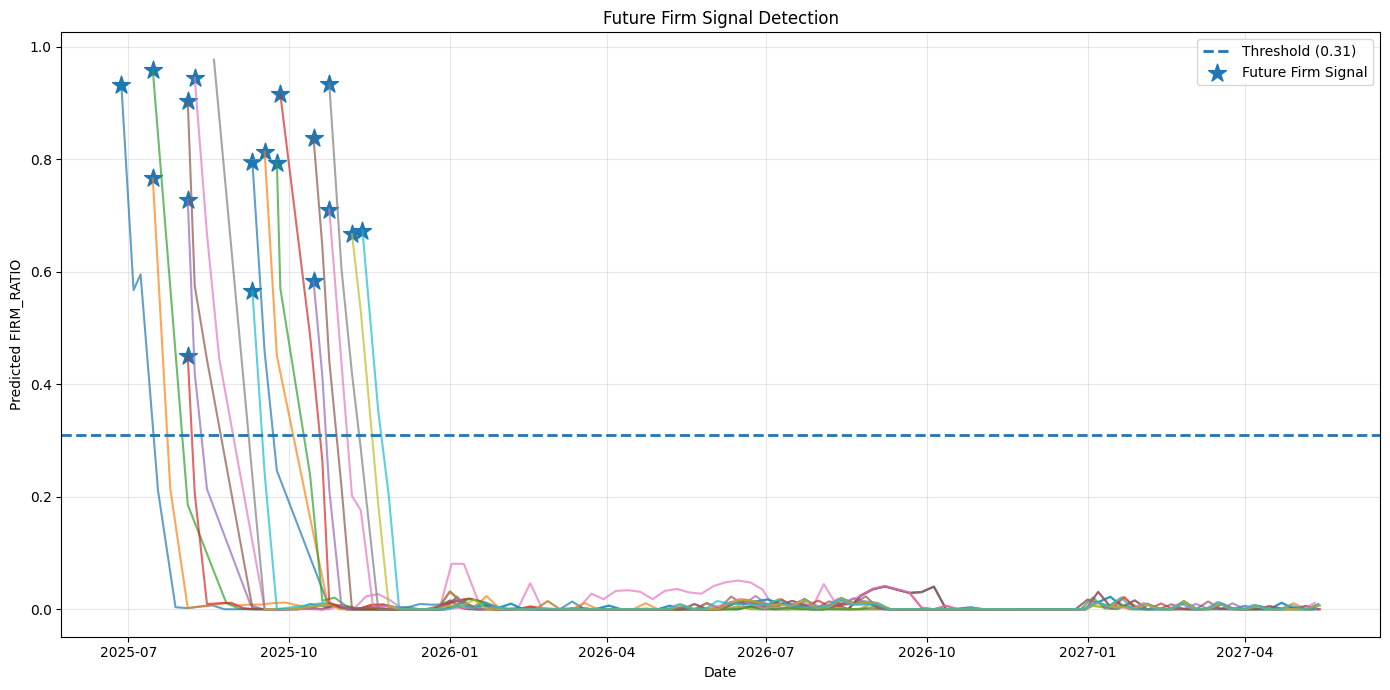


시각화 저장: /content/future_firm_signal_prediction.png

STEP 3 완료
최종 Threshold: 0.31


In [6]:
# ============================================================
# STEP 3: 미래 Firm 발생 위험 감지 평가
# - Step 1 정의와 일치:
#   FIRM_RATIO = 현재 이후 미래 4주 동안 is_firm=1 비율
# - 평가 기준:
#   FIRM_RATIO > 0 인 행 = 미래 4주 안에 실제 Firm 발생
#   FIRM_RATIO_Pred >= threshold 이면 감지 성공
# ============================================================

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt


class FirmTimingPredictor:
    def __init__(self, firm_ratio_model, threshold=0.05, window_size=4):
        self.model = firm_ratio_model
        self.threshold = threshold
        self.window_size = window_size

    def predict_one_release(self, release_df):
        release_df = release_df.sort_values("Date").reset_index(drop=True)

        pred = self.model.predict(release_df)

        result = release_df[
            ["ZF_PN", "ID_Release", "Date", "is_firm", "FIRM_RATIO"]
        ].copy()

        result["FIRM_RATIO_Pred"] = pred
        result["Week_Offset"] = np.arange(len(result))

        # 미래 4주 안에 실제 Firm이 있는 시점
        target = result[result["FIRM_RATIO"] > 0].copy()

        target_rows = []

        for idx, row in target.iterrows():
            future = result.iloc[idx + 1: idx + 1 + self.window_size]

            firm_rows = future[future["is_firm"] == 1]

            if len(firm_rows) > 0:
                first_firm = firm_rows.iloc[0]
                firm_week = int(first_firm["Week_Offset"])
                firm_date = first_firm["Date"]
                lead_weeks = firm_week - int(row["Week_Offset"])
            else:
                firm_week = None
                firm_date = None
                lead_weeks = None

            target_rows.append({
                "Signal_Week": int(row["Week_Offset"]),
                "Signal_Date": row["Date"],
                "Firm_Week": firm_week,
                "Firm_Date": firm_date,
                "Lead_Weeks": lead_weeks,
                "Actual_FIRM_RATIO_at_Signal": row["FIRM_RATIO"],
                "Pred_Ratio_at_Signal": row["FIRM_RATIO_Pred"]
            })

        if len(target_rows) > 0:
            first_target = target_rows[0]

            actual_status = "Future_Firm_Signal"
            signal_week = first_target["Signal_Week"]
            signal_date = first_target["Signal_Date"]
            firm_week = first_target["Firm_Week"]
            firm_date = first_target["Firm_Date"]
            lead_weeks = first_target["Lead_Weeks"]
            actual_ratio_at_signal = first_target["Actual_FIRM_RATIO_at_Signal"]
            pred_ratio_at_signal = first_target["Pred_Ratio_at_Signal"]

            detected = pred_ratio_at_signal >= self.threshold
            pred_status = "Detected" if detected else "Missed"

        else:
            actual_status = "No_Future_Firm_Signal"
            signal_week = None
            signal_date = None
            firm_week = None
            firm_date = None
            lead_weeks = None
            actual_ratio_at_signal = None
            pred_ratio_at_signal = None
            detected = False
            pred_status = "No_Target"

        summary = {
            "ZF_PN": result["ZF_PN"].iloc[0],
            "ID_Release": result["ID_Release"].iloc[0],
            "Start_Date": result["Date"].iloc[0],

            "Actual_Status": actual_status,
            "Signal_Week": signal_week,
            "Signal_Date": signal_date,
            "Firm_Week": firm_week,
            "Firm_Date": firm_date,
            "Lead_Weeks": lead_weeks,

            "Actual_FIRM_RATIO_at_Signal": actual_ratio_at_signal,
            "Pred_Ratio_at_Signal": pred_ratio_at_signal,
            "Threshold": self.threshold,
            "Pred_Status": pred_status,
            "Detected": detected,

            "Start_is_Firm": int(result["is_firm"].iloc[0]),
            "Start_Pred": result["FIRM_RATIO_Pred"].iloc[0],
            "Max_Pred": result["FIRM_RATIO_Pred"].max()
        }

        return summary, result

    def predict_all_releases(self, df, dataset_name="Test"):
        print("\n" + "=" * 60)
        print(f"STEP 3: {dataset_name} 미래 Firm 발생 위험 감지 평가")
        print("=" * 60)

        summaries = []
        prediction_dfs = []

        for _, release_df in df.groupby(["ZF_PN", "ID_Release"]):
            summary, pred_df = self.predict_one_release(release_df)
            summaries.append(summary)
            prediction_dfs.append(pred_df)

        summary_df = pd.DataFrame(summaries)
        prediction_df = pd.concat(prediction_dfs, ignore_index=True)

        print("\n[Release별 결과]")
        print(summary_df.to_string(index=False))

        self.print_summary(summary_df)

        return summary_df, prediction_df

    def print_summary(self, summary_df):
        print("\n[Actual Status 분포]")
        print(summary_df["Actual_Status"].value_counts(dropna=False))

        target = summary_df[
            summary_df["Actual_Status"] == "Future_Firm_Signal"
        ].copy()

        print("\n[미래 Firm 발생 신호 평가]")
        print(f"평가 대상 Release 수: {len(target)}")

        if len(target) > 0:
            print(f"탐지율: {target['Detected'].mean():.2%}")
            print(f"Detected 수: {target['Detected'].sum()} / {len(target)}")

            print("\n[Lead Weeks 통계]")
            print(target["Lead_Weeks"].describe())

            print("\n[Actual FIRM_RATIO at Signal 통계]")
            print(target["Actual_FIRM_RATIO_at_Signal"].describe())

            print("\n[Pred Ratio at Signal 통계]")
            print(target["Pred_Ratio_at_Signal"].describe())
        else:
            print("평가 가능한 미래 Firm 발생 신호가 없습니다.")

    def optimize_threshold(self, test_df, thresholds=None):
        print("\n" + "=" * 60)
        print("STEP 3-1: Threshold 확인")
        print("=" * 60)

        if thresholds is None:
            thresholds = np.arange(0.03, 0.31, 0.01)

        rows = []

        for th in thresholds:
            old_th = self.threshold
            self.threshold = th

            summary_df, _ = self.predict_all_releases_silent(test_df)

            target = summary_df[
                summary_df["Actual_Status"] == "Future_Firm_Signal"
            ].copy()

            if len(target) > 0:
                detect_rate = target["Detected"].mean()
                mean_pred = target["Pred_Ratio_at_Signal"].mean()
                min_pred = target["Pred_Ratio_at_Signal"].min()
                max_pred = target["Pred_Ratio_at_Signal"].max()
                mean_actual = target["Actual_FIRM_RATIO_at_Signal"].mean()
                target_cases = len(target)
            else:
                detect_rate = np.nan
                mean_pred = np.nan
                min_pred = np.nan
                max_pred = np.nan
                mean_actual = np.nan
                target_cases = 0

            rows.append({
                "Threshold": round(th, 3),
                "Target_Cases": target_cases,
                "Detect_Rate": detect_rate,
                "Mean_Actual_FIRM_RATIO": mean_actual,
                "Mean_Pred_Ratio": mean_pred,
                "Min_Pred_Ratio": min_pred,
                "Max_Pred_Ratio": max_pred
            })

            self.threshold = old_th

        result_df = pd.DataFrame(rows)

        print("\n[Threshold별 성능]")
        print(result_df.to_string(index=False))

        valid = result_df[result_df["Detect_Rate"].notna()].copy()

        if len(valid) > 0:
            max_detect = valid["Detect_Rate"].max()
            candidate = valid[valid["Detect_Rate"] == max_detect].copy()

            best_idx = candidate.sort_values(
                "Threshold",
                ascending=False
            ).index[0]

            self.threshold = result_df.loc[best_idx, "Threshold"]
        else:
            self.threshold = 0.05

        print(f"\n선택된 Threshold: {self.threshold:.3f}")

        return result_df

    def predict_all_releases_silent(self, df):
        summaries = []
        prediction_dfs = []

        for _, release_df in df.groupby(["ZF_PN", "ID_Release"]):
            summary, pred_df = self.predict_one_release(release_df)
            summaries.append(summary)
            prediction_dfs.append(pred_df)

        return pd.DataFrame(summaries), pd.concat(prediction_dfs, ignore_index=True)

    def predict_future(self, future_df):
        print("\n" + "=" * 60)
        print("STEP 3-2: Future 구간 예측")
        print("=" * 60)

        future_df = future_df.sort_values(
            ["ZF_PN", "ID_Release", "Date"]
        ).reset_index(drop=True)

        future_df["FIRM_RATIO_Pred"] = self.model.predict(future_df)

        print("\n[Future 예측 결과]")
        print(
            future_df[
                ["Date", "ID_Release", "FIRM_RATIO_Pred"]
            ].sort_values("FIRM_RATIO_Pred", ascending=False)
             .head(30)
             .to_string(index=False)
        )

        return future_df


def visualize_by_release(
    prediction_df,
    summary_df,
    threshold=0.05,
    save_path="/content/future_firm_signal_prediction.png"
):
    plt.figure(figsize=(14, 7))

    for (_, id_release), group in prediction_df.groupby(["ZF_PN", "ID_Release"]):
        group = group.sort_values("Date")

        plt.plot(
            group["Date"],
            group["FIRM_RATIO_Pred"],
            linewidth=1.5,
            alpha=0.7
        )

    plt.axhline(
        y=threshold,
        linestyle="--",
        linewidth=2,
        label=f"Threshold ({threshold:.2f})"
    )

    target = summary_df[
        summary_df["Actual_Status"] == "Future_Firm_Signal"
    ]

    if len(target) > 0:
        plt.scatter(
            target["Signal_Date"],
            target["Pred_Ratio_at_Signal"],
            marker="*",
            s=180,
            label="Future Firm Signal"
        )

    plt.xlabel("Date")
    plt.ylabel("Predicted FIRM_RATIO")
    plt.title("Future Firm Signal Detection")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

    print(f"\n시각화 저장: {save_path}")


# ================= 실행 =================

DATA_PATH = "/content/A0049000_only_selected_features.csv"
MODEL_PATH = "/content/firm_hybrid_model.pkl"

preparator = DataPreparator(
    filepath=DATA_PATH,
    window_size=4
)

train_df, test_df, future_df, feature_info = preparator.prepare_datasets()

with open(MODEL_PATH, "rb") as f:
    firm_ratio_model = pickle.load(f)

predictor = FirmTimingPredictor(
    firm_ratio_model=firm_ratio_model,
    threshold=0.05,
    window_size=4
)

threshold_result = predictor.optimize_threshold(test_df)

test_summary_df, test_prediction_df = predictor.predict_all_releases(
    test_df,
    dataset_name="Test"
)

future_prediction_df = predictor.predict_future(future_df)

visualize_by_release(
    prediction_df=test_prediction_df,
    summary_df=test_summary_df,
    threshold=predictor.threshold,
    save_path="/content/future_firm_signal_prediction.png"
)

threshold_result.to_csv(
    "/content/threshold_optimization_future_firm_signal.csv",
    index=False,
    encoding="utf-8-sig"
)

test_summary_df.to_csv(
    "/content/test_future_firm_signal_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

test_prediction_df.to_csv(
    "/content/test_future_firm_signal_detail.csv",
    index=False,
    encoding="utf-8-sig"
)

future_prediction_df.to_csv(
    "/content/future_firm_signal_predictions.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n" + "=" * 60)
print("STEP 3 완료")
print("=" * 60)
print(f"최종 Threshold: {predictor.threshold}")


In [7]:
# STEP 4: Quantity 회귀 예측 모델
# Step 1 반환값: train_df, test_df, future_df, feature_info
# Step 2의 FIRM_RATIO_Pred를 Quantity 예측 피처로 사용

import numpy as np
import pandas as pd
import pickle
import xgboost as xgb

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


class QuantityRegressionModel:
    def __init__(self, feature_cols):
        self.feature_cols = feature_cols
        self.available_features = None
        self.model = None

    def add_firm_ratio_prediction(self, df, firm_ratio_model):
        df = df.copy()

        df["FIRM_RATIO_Pred"] = firm_ratio_model.predict(df)

        df["Release_Max_FIRM_RATIO_Pred"] = (
            df.groupby(["ZF_PN", "ID_Release"])["FIRM_RATIO_Pred"]
            .transform("max")
        )

        df["Release_Mean_FIRM_RATIO_Pred"] = (
            df.groupby(["ZF_PN", "ID_Release"])["FIRM_RATIO_Pred"]
            .transform("mean")
        )

        df["historical_avg_qty"] = (
            df.groupby(["ZF_PN", "ID_Release"])["Quantity"]
            .transform(lambda x: x.shift(1).expanding().mean())
        )

        df["cumulative_qty"] = (
            df.groupby(["ZF_PN", "ID_Release"])["Quantity"]
            .transform(lambda x: x.shift(1).cumsum())
        )

        df = df.replace([np.inf, -np.inf], np.nan)
        df = df.fillna(0)

        return df

    def evaluate(self, y_true, y_pred, name="Model"):
        y_pred = np.maximum(y_pred, 0)

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)

        if len(np.unique(y_true)) > 1:
            r2 = r2_score(y_true, y_pred)
        else:
            r2 = np.nan

        nonzero_mask = y_true != 0

        if nonzero_mask.sum() > 0:
            mape = np.mean(
                np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
            )
        else:
            mape = np.nan

        print(f"\n[{name}]")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE : {mae:.4f}")
        print(f"  R²  : {r2:.4f}")
        print(f"  MAPE: {mape:.2%}")

        return {
            "rmse": rmse,
            "mae": mae,
            "r2": r2,
            "mape": mape
        }

    def fit(self, train_df, eval_df, firm_ratio_model):
        print("\n" + "=" * 60)
        print("STEP 4: Quantity 회귀 모델 학습")
        print("=" * 60)

        train_df = self.add_firm_ratio_prediction(train_df, firm_ratio_model)
        eval_df = self.add_firm_ratio_prediction(eval_df, firm_ratio_model)

        train_firm = train_df[train_df["is_firm"] == 1].copy()
        eval_firm = eval_df[eval_df["is_firm"] == 1].copy()

        print("\n[Firm 주문 필터링]")
        print(f"  Train 전체: {len(train_df):,}행")
        print(f"  Train Firm: {len(train_firm):,}행 ({len(train_firm)/len(train_df)*100:.1f}%)")
        print(f"  Eval/Test 전체: {len(eval_df):,}행")
        print(f"  Eval/Test Firm: {len(eval_firm):,}행 ({len(eval_firm)/len(eval_df)*100:.1f}%)")

        if len(train_firm) == 0:
            train_firm = train_df.copy()

        if len(eval_firm) == 0:
            eval_firm = eval_df.copy()

        self.available_features = [
            col for col in self.feature_cols
            if col in train_firm.columns
            and pd.api.types.is_numeric_dtype(train_firm[col])
        ]

        print(f"\n[사용 피처 {len(self.available_features)}개]")
        for col in self.available_features:
            print(f"  - {col}")

        X_train = train_firm[self.available_features]
        y_train = train_firm["Quantity"]

        X_eval = eval_firm[self.available_features]
        y_eval = eval_firm["Quantity"]

        self.model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            max_depth=3,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=5,
            gamma=0.1,
            reg_alpha=0.5,
            reg_lambda=3.0,
            random_state=42
        )

        self.model.fit(
            X_train,
            y_train,
            eval_set=[(X_eval, y_eval)],
            verbose=False
        )

        train_pred = self.predict(train_firm)
        eval_pred = self.predict(eval_firm)

        train_metrics = self.evaluate(y_train.values, train_pred, "Train Quantity")
        eval_metrics = self.evaluate(y_eval.values, eval_pred, "Eval/Test Quantity")

        importance_df = pd.DataFrame({
            "Feature": self.available_features,
            "Importance": self.model.feature_importances_
        }).sort_values("Importance", ascending=False)

        print("\n[Feature Importance Top 15]")
        print(importance_df.head(15).to_string(index=False))

        return {
            "train_metrics": train_metrics,
            "eval_metrics": eval_metrics,
            "feature_importance": importance_df
        }

    def predict(self, df):
        X = df[self.available_features]
        pred = self.model.predict(X)
        pred = np.maximum(pred, 0)
        return pred

    def evaluate_test(self, test_df, firm_ratio_model):
        print("\n" + "=" * 60)
        print("STEP 4-1: Test Quantity 평가")
        print("=" * 60)

        test_df = self.add_firm_ratio_prediction(test_df, firm_ratio_model)
        test_firm = test_df[test_df["is_firm"] == 1].copy()

        if len(test_firm) == 0:
            test_firm = test_df.copy()

        y_test = test_firm["Quantity"].values
        pred = self.predict(test_firm)

        test_metrics = self.evaluate(y_test, pred, "Final Test Quantity")

        result_df = test_firm.copy()
        result_df["Quantity_Actual"] = y_test
        result_df["Quantity_Pred"] = pred
        result_df["Quantity_Error"] = result_df["Quantity_Actual"] - result_df["Quantity_Pred"]
        result_df["Quantity_Abs_Error"] = np.abs(result_df["Quantity_Error"])

        print("\n[Test 예측 결과 상위 30개]")
        print(
            result_df[
                [
                    "Date",
                    "ID_Release",
                    "Quantity_Actual",
                    "Quantity_Pred",
                    "Quantity_Error",
                    "FIRM_RATIO_Pred"
                ]
            ].head(30).to_string(index=False)
        )

        return result_df, test_metrics

    def predict_future(self, future_df, firm_ratio_model):
        print("\n" + "=" * 60)
        print("STEP 4-2: Future Quantity 예측")
        print("=" * 60)

        future_df = self.add_firm_ratio_prediction(future_df, firm_ratio_model)

        pred = self.predict(future_df)

        future_result_df = future_df.copy()
        future_result_df["Quantity_Pred"] = pred

        print("\n[Future Quantity 예측 상위 30개]")
        print(
            future_result_df[
                [
                    "Date",
                    "ID_Release",
                    "Quantity",
                    "Quantity_Pred",
                    "FIRM_RATIO_Pred"
                ]
            ].sort_values("FIRM_RATIO_Pred", ascending=False)
             .head(30)
             .to_string(index=False)
        )

        return future_result_df

    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump(self, f)

        print(f"\n✓ Quantity 모델 저장: {path}")


# ================= 실행 =================

if __name__ == "__main__":
    DATA_PATH = "/content/A0049000_only_selected_features.csv"
    FIRM_MODEL_PATH = "/content/firm_hybrid_model.pkl"

    QUANTITY_MODEL_PATH = "/content/quantity_model.pkl"
    TEST_RESULT_SAVE_PATH = "/content/quantity_test_predictions.csv"
    FUTURE_RESULT_SAVE_PATH = "/content/quantity_future_predictions.csv"

    preparator = DataPreparator(
        filepath=DATA_PATH,
        window_size=4
    )

    train_df, test_df, future_df, feature_info = preparator.prepare_datasets()

    with open(FIRM_MODEL_PATH, "rb") as f:
        firm_ratio_model = pickle.load(f)

    quantity_features = (
        feature_info["internal_features"]
        + feature_info["lag_features"]
        + [
            "FIRM_RATIO_Pred",
            "Release_Max_FIRM_RATIO_Pred",
            "Release_Mean_FIRM_RATIO_Pred",
            "historical_avg_qty",
            "cumulative_qty"
        ]
    )

    quantity_model = QuantityRegressionModel(
        feature_cols=quantity_features
    )

    results = quantity_model.fit(
        train_df=train_df,
        eval_df=test_df,
        firm_ratio_model=firm_ratio_model
    )

    test_result_df, test_metrics = quantity_model.evaluate_test(
        test_df=test_df,
        firm_ratio_model=firm_ratio_model
    )

    future_result_df = quantity_model.predict_future(
        future_df=future_df,
        firm_ratio_model=firm_ratio_model
    )

    quantity_model.save(QUANTITY_MODEL_PATH)

    test_result_df.to_csv(
        TEST_RESULT_SAVE_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    future_result_df.to_csv(
        FUTURE_RESULT_SAVE_PATH,
        index=False,
        encoding="utf-8-sig"
    )

    print("\n" + "=" * 60)
    print("✓ STEP 4 완료")
    print("=" * 60)
    print(f"모델 저장: {QUANTITY_MODEL_PATH}")
    print(f"Test 결과 저장: {TEST_RESULT_SAVE_PATH}")
    print(f"Future 결과 저장: {FUTURE_RESULT_SAVE_PATH}")

STEP 1-1. 데이터 로드
데이터 크기: (5359, 19)
Demand Date 범위: 2024-05-27 00:00:00 ~ 2027-07-30 00:00:00
Release_Date 범위: 2024-05-21 00:00:00 ~ 2025-11-10 00:00:00
품명 수: 1
ID_Release 수: 77
is_firm 평균: 0.057

STEP 1-2. Feature Engineering
✓ Feature Engineering 완료
  - Rolling 통계량은 과거 데이터만 사용

STEP 1-3. FIRM_RATIO 타깃 생성
✓ FIRM_RATIO 생성 완료
  정의: 현재 이후 미래 4주 동안 is_firm=1 비율
  유효 데이터: 5,282 / 5,359
  평균: 0.024
  표준편차: 0.127
  최소값: 0.000
  최대값: 1.000

[FIRM_RATIO 분포]
  0.00: 5,052개
  0.25: 74개
  0.50: 68개
  0.75: 48개
  1.00: 40개

STEP 1-4. 변수 그룹 분리

외부 변수 Lag Features: 4개
  - OIL_FACTOR__level_lag11
  - SHIP_FACTOR__level_lag6
  - GSCPI__level_lag14
  - Brazil_CPI__level_lag3

내부 변수 Internal Features: 13개
  - Year
  - Day
  - Month_Num
  - DayOfYear
  - WeekOfYear
  - Quarter
  - DayOfWeek
  - DaysSinceRelease
  - WeeksSinceRelease
  - Quantity_Rolling_Mean_2w
  - Quantity_Rolling_Std_2w
  - Quantity_Rolling_Mean_4w
  - Quantity_Rolling_Std_4w

STEP 1-5. 결측치 처리

[처리 전 결측치]
  FIRM_RATIO: 77개
  Quantity_R